In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.2 MB/s eta 0:00:00


In [ ]:
!pip install datasets

In [ ]:
# Download just a few sample images from AP-10K via gdown (Google Drive)
!pip install gdown

# Official AP-10K download (annotations + images)
# !gdown --fuzzy "https://drive.google.com/file/d/1-FNNGcdtAQRehYYkGY1y4wzFNg4iWNad/view" -O /content/ap10k.zip
# !unzip -q /content/ap10k.zip -d /content/ap10k

In [ ]:
# Cell 2: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Cell 3: Extract AP-10K (using the zip file saved on the drive)
import zipfile, os
zip_path = '/content/drive/MyDrive/ap-10k.zip'
extract_path = '/content/ap10k'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Success!")

Mounted at /content/drive
Success!


In [ ]:
import os
for root, dirs, files in os.walk('/content/ap10k'):
    for f in files:
        print(os.path.join(root, f))

/content/ap10k/ap-10k/annotations/ap10k-val-split2.json
/content/ap10k/ap-10k/annotations/ap10k-test-split1.json
/content/ap10k/ap-10k/annotations/ap10k-val-split1.json
/content/ap10k/ap-10k/annotations/ap10k-train-split2.json
/content/ap10k/ap-10k/annotations/ap10k-test-split2.json
/content/ap10k/ap-10k/annotations/ap10k-val-split3.json
/content/ap10k/ap-10k/annotations/ap10k-train-split3.json
/content/ap10k/ap-10k/annotations/ap10k-test-split3.json
/content/ap10k/ap-10k/annotations/ap10k-train-split1.json
/content/ap10k/ap-10k/data/000000037841.jpg
/content/ap10k/ap-10k/data/000000001150.jpg
/content/ap10k/ap-10k/data/000000037679.jpg
/content/ap10k/ap-10k/data/000000037743.jpg
/content/ap10k/ap-10k/data/000000030806.jpg
/content/ap10k/ap-10k/data/000000050270.jpg
/content/ap10k/ap-10k/data/000000030004.jpg
/content/ap10k/ap-10k/data/000000018360.jpg
/content/ap10k/ap-10k/data/000000004434.jpg
/content/ap10k/ap-10k/data/000000000108.jpg
/content/ap10k/ap-10k/data/000000012507.jpg
/co

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/ap10k/ap-10k/data/000000056589.jpg: 480x640 (no detections), 80.3ms
Speed: 13.7ms preprocess, 80.3ms inference, 5.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/output/zeroshot


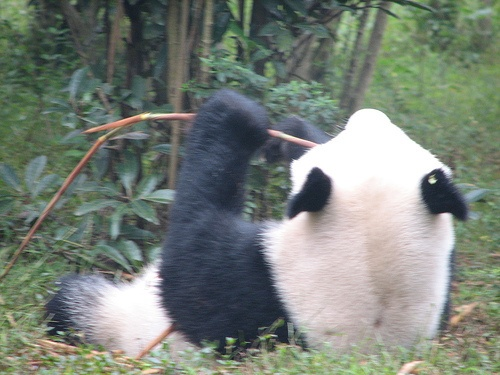

In [ ]:
from ultralytics import YOLO
from IPython.display import Image as IPImage
import os

model = YOLO('yolov8n-pose.pt')

# running on a sample image from dataset
sample = '/content/ap10k/ap-10k/data/000000056589.jpg'

results = model(sample, save=True, project='/content/output', name='zeroshot')

IPImage(filename='/content/output/zeroshot/000000056589.jpg')

Running inference on 1000 images...
  0/1000...
  100/1000...
  200/1000...
  300/1000...
  400/1000...
  500/1000...
  600/1000...
  700/1000...
  800/1000...
  900/1000...
Done! Plotting results...


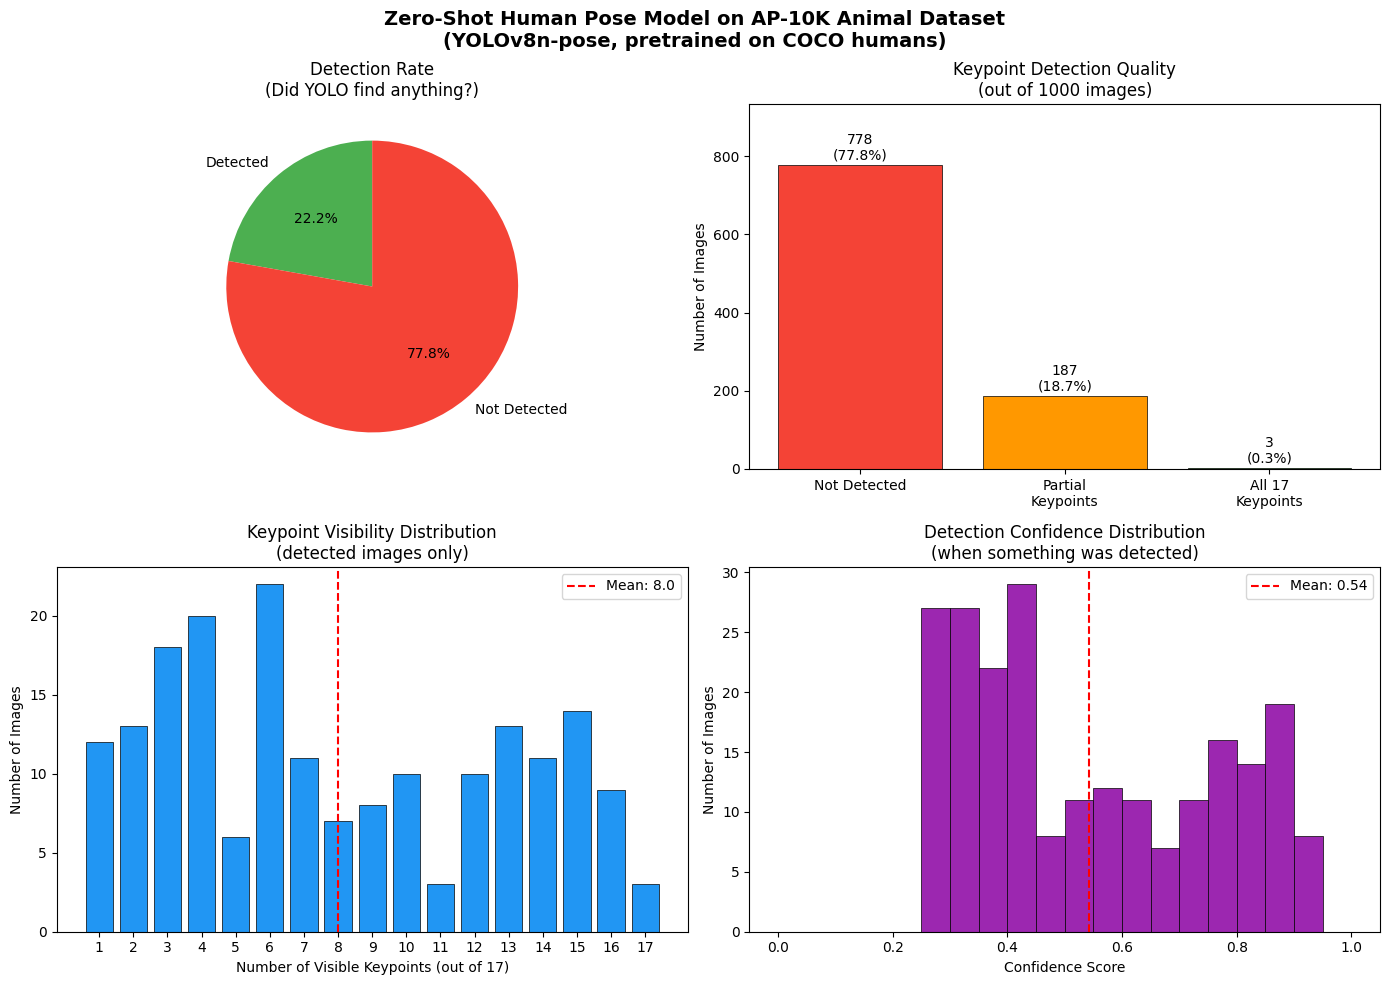


ZERO-SHOT EXPERIMENT SUMMARY (n=1000)
Detection rate:        22.2%
No detection:          77.8%
All 17 kpts visible:   0.3%
Partial kpts visible:  18.7%
Mean confidence:       0.54
Mean visible kpts:     8.0 / 17


In [ ]:
from ultralytics import YOLO
from IPython.display import Image as IPImage
import os, json, random
import matplotlib.pyplot as plt
import numpy as np

model = YOLO('yolov8n-pose.pt')

# Get 1000 random images
img_dir = '/content/ap10k/ap-10k/data'
all_images = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith('.jpg')]
sample_images = random.sample(all_images, 1000)

# Run inference and collect stats
results_data = {
    'detected': 0,        # YOLO found at least one person/animal
    'not_detected': 0,    # YOLO found nothing
    'keypoints_full': 0,  # All 17 keypoints visible
    'keypoints_partial': 0, # Some keypoints visible
    'confidence_scores': [],
    'keypoints_per_image': [],
    'visible_keypoints_per_image': []
}

print("Running inference on 1000 images...")
for i, img_path in enumerate(sample_images):
    if i % 100 == 0:
        print(f"  {i}/1000...")

    result = model(img_path, verbose=False)[0]

    if result.keypoints is None or len(result.keypoints) == 0:
        results_data['not_detected'] += 1
        results_data['keypoints_per_image'].append(0)
        results_data['visible_keypoints_per_image'].append(0)
    else:
        results_data['detected'] += 1

        # Get best detection (highest confidence)
        if result.boxes is not None and len(result.boxes) > 0:
            conf = float(result.boxes.conf[0])
            results_data['confidence_scores'].append(conf)

        # Count visible keypoints (confidence > 0.5)
        kpts = result.keypoints.data[0]  # shape [17, 3]
        visible = int((kpts[:, 2] > 0.5).sum())
        results_data['keypoints_per_image'].append(17)
        results_data['visible_keypoints_per_image'].append(visible)

        if visible == 17:
            results_data['keypoints_full'] += 1
        elif visible > 0:
            results_data['keypoints_partial'] += 1

print("Done! Plotting results...")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Zero-Shot Human Pose Model on AP-10K Animal Dataset\n(YOLOv8n-pose, pretrained on COCO humans)',
             fontsize=14, fontweight='bold')

# 1. Detection rate pie chart
ax1 = axes[0, 0]
labels = ['Detected', 'Not Detected']
sizes = [results_data['detected'], results_data['not_detected']]
colors = ['#4CAF50', '#F44336']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Detection Rate\n(Did YOLO find anything?)')

# 2. Keypoint visibility breakdown (bar chart)
ax2 = axes[0, 1]
categories = ['Not Detected', 'Partial\nKeypoints', 'All 17\nKeypoints']
counts = [results_data['not_detected'], results_data['keypoints_partial'], results_data['keypoints_full']]
colors2 = ['#F44336', '#FF9800', '#4CAF50']
bars = ax2.bar(categories, counts, color=colors2, edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/10:.1f}%)', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Number of Images')
ax2.set_title('Keypoint Detection Quality\n(out of 1000 images)')
ax2.set_ylim(0, max(counts) * 1.2)

# 3. Histogram of visible keypoints per detected image
ax3 = axes[1, 0]
visible_kpts = [v for v in results_data['visible_keypoints_per_image'] if v > 0]
if visible_kpts:
    ax3.hist(visible_kpts, bins=17, range=(0.5, 17.5), color='#2196F3',
             edgecolor='black', linewidth=0.5, rwidth=0.8)
ax3.set_xlabel('Number of Visible Keypoints (out of 17)')
ax3.set_ylabel('Number of Images')
ax3.set_title('Keypoint Visibility Distribution\n(detected images only)')
ax3.set_xticks(range(1, 18))
ax3.axvline(x=np.mean(visible_kpts) if visible_kpts else 0,
            color='red', linestyle='--', label=f'Mean: {np.mean(visible_kpts):.1f}' if visible_kpts else '')
ax3.legend()

# 4. Confidence score distribution
ax4 = axes[1, 1]
if results_data['confidence_scores']:
    ax4.hist(results_data['confidence_scores'], bins=20, range=(0, 1),
             color='#9C27B0', edgecolor='black', linewidth=0.5)
    ax4.axvline(x=np.mean(results_data['confidence_scores']),
                color='red', linestyle='--',
                label=f'Mean: {np.mean(results_data["confidence_scores"]):.2f}')
    ax4.legend()
ax4.set_xlabel('Confidence Score')
ax4.set_ylabel('Number of Images')
ax4.set_title('Detection Confidence Distribution\n(when something was detected)')

plt.tight_layout()
plt.savefig('/content/zero_shot_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"\n{'='*50}")
print(f"ZERO-SHOT EXPERIMENT SUMMARY (n=1000)")
print(f"{'='*50}")
print(f"Detection rate:        {results_data['detected']/10:.1f}%")
print(f"No detection:          {results_data['not_detected']/10:.1f}%")
print(f"All 17 kpts visible:   {results_data['keypoints_full']/10:.1f}%")
print(f"Partial kpts visible:  {results_data['keypoints_partial']/10:.1f}%")
if results_data['confidence_scores']:
    print(f"Mean confidence:       {np.mean(results_data['confidence_scores']):.2f}")
if visible_kpts:
    print(f"Mean visible kpts:     {np.mean(visible_kpts):.1f} / 17")

In [ ]:
# ============================================================
# Step 1: AP-10K JSON label -> YOLO txt format
# ============================================================
from tqdm import tqdm
import json
import os
from pathlib import Path

ap10k_root = '/content/ap10k/ap-10k'

anno_files = {
    'train': os.path.join(ap10k_root, 'annotations/ap10k-train-split1.json'),
    'val': os.path.join(ap10k_root, 'annotations/ap10k-val-split1.json')
}

img_dir = os.path.join(ap10k_root, 'data')

label_out = {
    'train': os.path.join(ap10k_root, 'labels/train'),
    'val': os.path.join(ap10k_root, 'labels/val')
}

img_out = {
    'train': os.path.join(ap10k_root, 'images/train'),
    'val': os.path.join(ap10k_root, 'images/val')
}

for split in ['train', 'val']:
  os.makedirs(label_out[split], exist_ok=True)
  os.makedirs(img_out[split], exist_ok=True)

def convert_coco_to_yolo(anno_path, label_dir, img_src_dir, img_dst_dir):
  with open(anno_path, 'r') as f:
    coco = json.load(f)

  img_info = {img['id']: img for img in coco['images']}

  anno_by_img = {}
  for ann in coco['annotations']:
    anno_by_img.setdefault(ann['image_id'], []).append(ann)

  skipped = 0

  for img_id, annos in tqdm(anno_by_img.items(), desc=f'Converting {split}'):
    info = img_info[img_id]
    img_w, img_h = info['width'], info['height']
    filename = info['file_name']

    yolo_lines = []

    for ann in annos:
      bbox = ann.get('bbox', [])
      if len(bbox) != 4:
        skipped += 1
        continue
      bx, by, bw, bh = bbox
      xc = (bx + bw/2) / img_w
      yc = (by + bh/2) / img_h
      nw = bw / img_w
      nh = bh / img_h

      kpts = ann.get('keypoints', [])
      if len(kpts) != 51:
        skipped += 1
        continue

      kpt_parts = []
      for k in range(17):
        kx = kpts[k*3] / img_w
        ky = kpts[k*3+1] / img_h
        kv = kpts[k*3+2]
        kpt_parts.append(f'{kx:.6f} {ky:.6f} {int(kv)}')

      line = f'0 {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f} {" ".join(kpt_parts)}'
      yolo_lines.append(line)

    if not yolo_lines:
      continue

    stem = Path(filename).stem
    with open(os.path.join(label_dir, f'{stem}.txt'), 'w') as f:
      f.write('\n'.join(yolo_lines))

    src = os.path.join(img_src_dir, filename)
    dst = os.path.join(img_dst_dir, filename)
    if os.path.exists(src) and not os.path.exists(dst):
      os.symlink(src, dst)

  print(f'Skipped {skipped} images')

for split, anno_path in anno_files.items():
  print(f'Converting {split}...')
  convert_coco_to_yolo(anno_path, label_out[split], img_dir, img_out[split])
  print(f' -> label: {len(os.listdir(label_out[split]))}')
  print(f' -> images: {len(os.listdir(img_out[split]))}')

print("completed transition!")

Converting train...


Converting train: 100%|██████████| 7023/7023 [00:01<00:00, 5599.46it/s]


Skipped 0 images
 -> label: 7023
 -> images: 7023
Converting val...


Converting val: 100%|██████████| 995/995 [00:00<00:00, 5582.19it/s]

Skipped 0 images
 -> label: 995
 -> images: 995
completed transition!


In [ ]:
# ============================================================
# Step 2: data.yml
# ============================================================

yaml_content = """
path: /content/ap10k/ap-10k
train: images/train
val:   images/val

nc: 1
names: ['animal']

# 17 keypoints, each with (x, y, visibility)
kpt_shape: [17, 3]

# Which keypoints should be connected by lines (to reflect the animal's skeletal structure)
# 0:LeftEye 1:RightEye 2:Nose 3:LeftShoulder 4:RightShoulder
# 5:LeftElbow 6:RightElbow 7:LeftFrontPaw 8:RightFrontPaw
# 9:LeftHip 10:RightHip 11:LeftKnee 12:RightKnee
# 13:LeftBackPaw 14:RightBackPaw 15:Neck 16:TailBase
skeleton:
  - [0, 2]    # Left eye → Nose
  - [1, 2]    # Right eye → Nose
  - [2, 15]   # Nose → Neck
  - [15, 3]   # Neck → Left shoulder
  - [15, 4]   # Neck → Right shoulder
  - [3, 5]    # Left shoulder → Left elbow (mid-forearm)
  - [4, 6]    # Right shoulder → Right elbow
  - [5, 7]    # Left elbow → Left front paw
  - [6, 8]    # Right elbow → Right front paw
  - [15, 16]  # Neck → Tail (spine)
  - [16, 9]   # Tail → Left hip
  - [16, 10]  # Tail → Right hip
  - [9, 11]   # Left hip → Left knee (mid-hind leg)
  - [10, 12]  # Right hip → Right knee
  - [11, 13]  # Left knee → Left hind leg
  - [12, 14]  # Right knee → Right hind leg
""".strip()

yaml_path = '/content/ap10k/ap-10k/data.yaml'

with open(yaml_path, 'w') as f:
  f.write(yaml_content)

print("data.yaml created!")
print(yaml_content)

data.yaml created!
path: /content/ap10k/ap-10k
train: images/train
val:   images/val

nc: 1
names: ['animal']

# 17 keypoints, each with (x, y, visibility)
kpt_shape: [17, 3]

# Which keypoints should be connected by lines (to reflect the animal's skeletal structure)
# 0:LeftEye 1:RightEye 2:Nose 3:LeftShoulder 4:RightShoulder
# 5:LeftElbow 6:RightElbow 7:LeftFrontPaw 8:RightFrontPaw
# 9:LeftHip 10:RightHip 11:LeftKnee 12:RightKnee
# 13:LeftBackPaw 14:RightBackPaw 15:Neck 16:TailBase
skeleton:
  - [0, 2]    # Left eye → Nose
  - [1, 2]    # Right eye → Nose
  - [2, 15]   # Nose → Neck
  - [15, 3]   # Neck → Left shoulder
  - [15, 4]   # Neck → Right shoulder
  - [3, 5]    # Left shoulder → Left elbow (mid-forearm)
  - [4, 6]    # Right shoulder → Right elbow
  - [5, 7]    # Left elbow → Left front paw
  - [6, 8]    # Right elbow → Right front paw
  - [15, 16]  # Neck → Tail (spine)
  - [16, 9]   # Tail → Left hip
  - [16, 10]  # Tail → Right hip
  - [9, 11]   # Left hip → Left knee (mi

In [ ]:
!nvidia-smi

Thu May  7 02:53:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             27W /   70W |     199MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:

# ============================================================
# Step 3: yolov8-pose fine tuning
# ============================================================

from ultralytics import YOLO

model = YOLO('yolov8n-pose.pt')
print(f"parameters: {sum(p.numel() for p in model.model.parameters()):,}")

results = model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=16,
    lr0=0.001,
    lrf=0.01,
    freeze=10,
    pose=12.0,
    project='/content/runs',
    name='ap10k_finetune',
    exist_ok=True,
    verbose=True,
)

print("Finished fine-tuning")
print("Saved at: /content/runs/ap10k_finetune/")

parameters: 3,295,470
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ap10k/ap-10k/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ap10k_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

In [ ]:
# ============================================================
# Step 4: comparison Fine-tuned vs zero-shot
# ============================================================

from tqdm import tqdm
import cv2

ft_model = YOLO('/content/runs/ap10k_finetune/weights/best.pt')
print("model loaded")

val_img_dir = '/content/ap10k/ap-10k/images/val'
val_label_dir = '/content/ap10k/ap-10k/labels/val'

all_val_imgs = [f for f in os.listdir(val_img_dir) if f.endswith('.jpg')]
random.seed(42)
test_sample = random.sample(all_val_imgs, min(200, len(all_val_imgs)))
print(f"val images: {len(test_sample)}")

def compute_pck(pred_kpts, gt_kpts_flat, bbox_px, alpha=0.1):
  _, _, bw, bh = bbox_px
  threshold = alpha * max(bw, bh)
  correct, n_visible = 0, 0

  for k in range(17):
    gx = gt_kpts_flat[k*3]
    gy = gt_kpts_flat[k*3+1]
    gv = gt_kpts_flat[k*3+2]
    if gv == 0:
      continue
    n_visible += 1
    if k < len(pred_kpts):
      dist = np.sqrt((pred_kpts[k][0]-gx)**2 + (pred_kpts[k][1]-gy)**2)
      if dist <= threshold:
        correct += 1

  return (correct / n_visible if n_visible > 0 else None), n_visible


detection_count = 0
pck_scores, visible_kpt_counts = [], []

for fname in tqdm(test_sample, desc="evaluating"):
  img_path = os.path.join(val_img_dir, fname)
  label_path = os.path.join(val_label_dir, fname.replace('.jpg', '.txt'))
  if not os.path.exists(label_path):
    continue

  with open(label_path) as f:
    lines = f.readlines()
  if not lines:
    continue

  img = cv2.imread(img_path)
  if img is None:
    continue
  ih, iw = img.shape[:2]

  gt = list(map(float, lines[0].split()))
  bxc, byc, bw_n, bh_n = gt[1:5]
  gt_bbox_px = [(bxc-bw_n/2)*iw, (byc-bh_n/2)*ih, bw_n*iw, bh_n*ih]
  gt_kpts_px = []

  for k in range(17):
    gt_kpts_px += [gt[5+k*3]*iw, gt[5+k*3+1]*ih, gt[5+k*3+2]]

  result = ft_model(img_path, conf=0.25, verbose=False)[0]

  if result.keypoints is None or len(result.keypoints) == 0:
    continue

  detection_count += 1
  best_idx = result.boxes.conf.argmax().item()
  pred_kpts = result.keypoints.data[best_idx].cpu().numpy()
  visible_kpt_counts.append(int((pred_kpts[:, 2] > 0.5).sum()))

  pck, _ = compute_pck(pred_kpts[:, :2], gt_kpts_px, gt_bbox_px)
  if pck is not None:
    pck_scores.append(pck)


det_rate = detection_count / len(test_sample) *100
mean_pck = np.mean(pck_scores) * 100 if pck_scores else 0
mean_vis = np.mean(visible_kpt_counts) if visible_kpt_counts else 0

print("\n" + "="*50)
print("  📊 Fine-tuned model eval result")
print("="*50)
print(f"  Detection Rate:         {det_rate:.1f}%")
print(f"  Mean Visible Keypoints: {mean_vis:.1f} / 17")
print(f"  PCK@0.1:                {mean_pck:.1f}%")
print("="*50)
print(f"\n  Compare to Zero-shot: 19.3% → {det_rate:.1f}% (Detection Rate)")
print(f"                  8.8/17 → {mean_vis:.1f}/17 (Visible Keypoints)")

model loaded
val images: 200


evaluating: 100%|██████████| 200/200 [00:05<00:00, 34.78it/s]


  📊 Fine-tuned model eval result
  Detection Rate:         97.5%
  Mean Visible Keypoints: 10.1 / 17
  PCK@0.1:                62.0%

  Compare to Zero-shot: 19.3% → 97.5% (Detection Rate)
                  8.8/17 → 10.1/17 (Visible Keypoints)


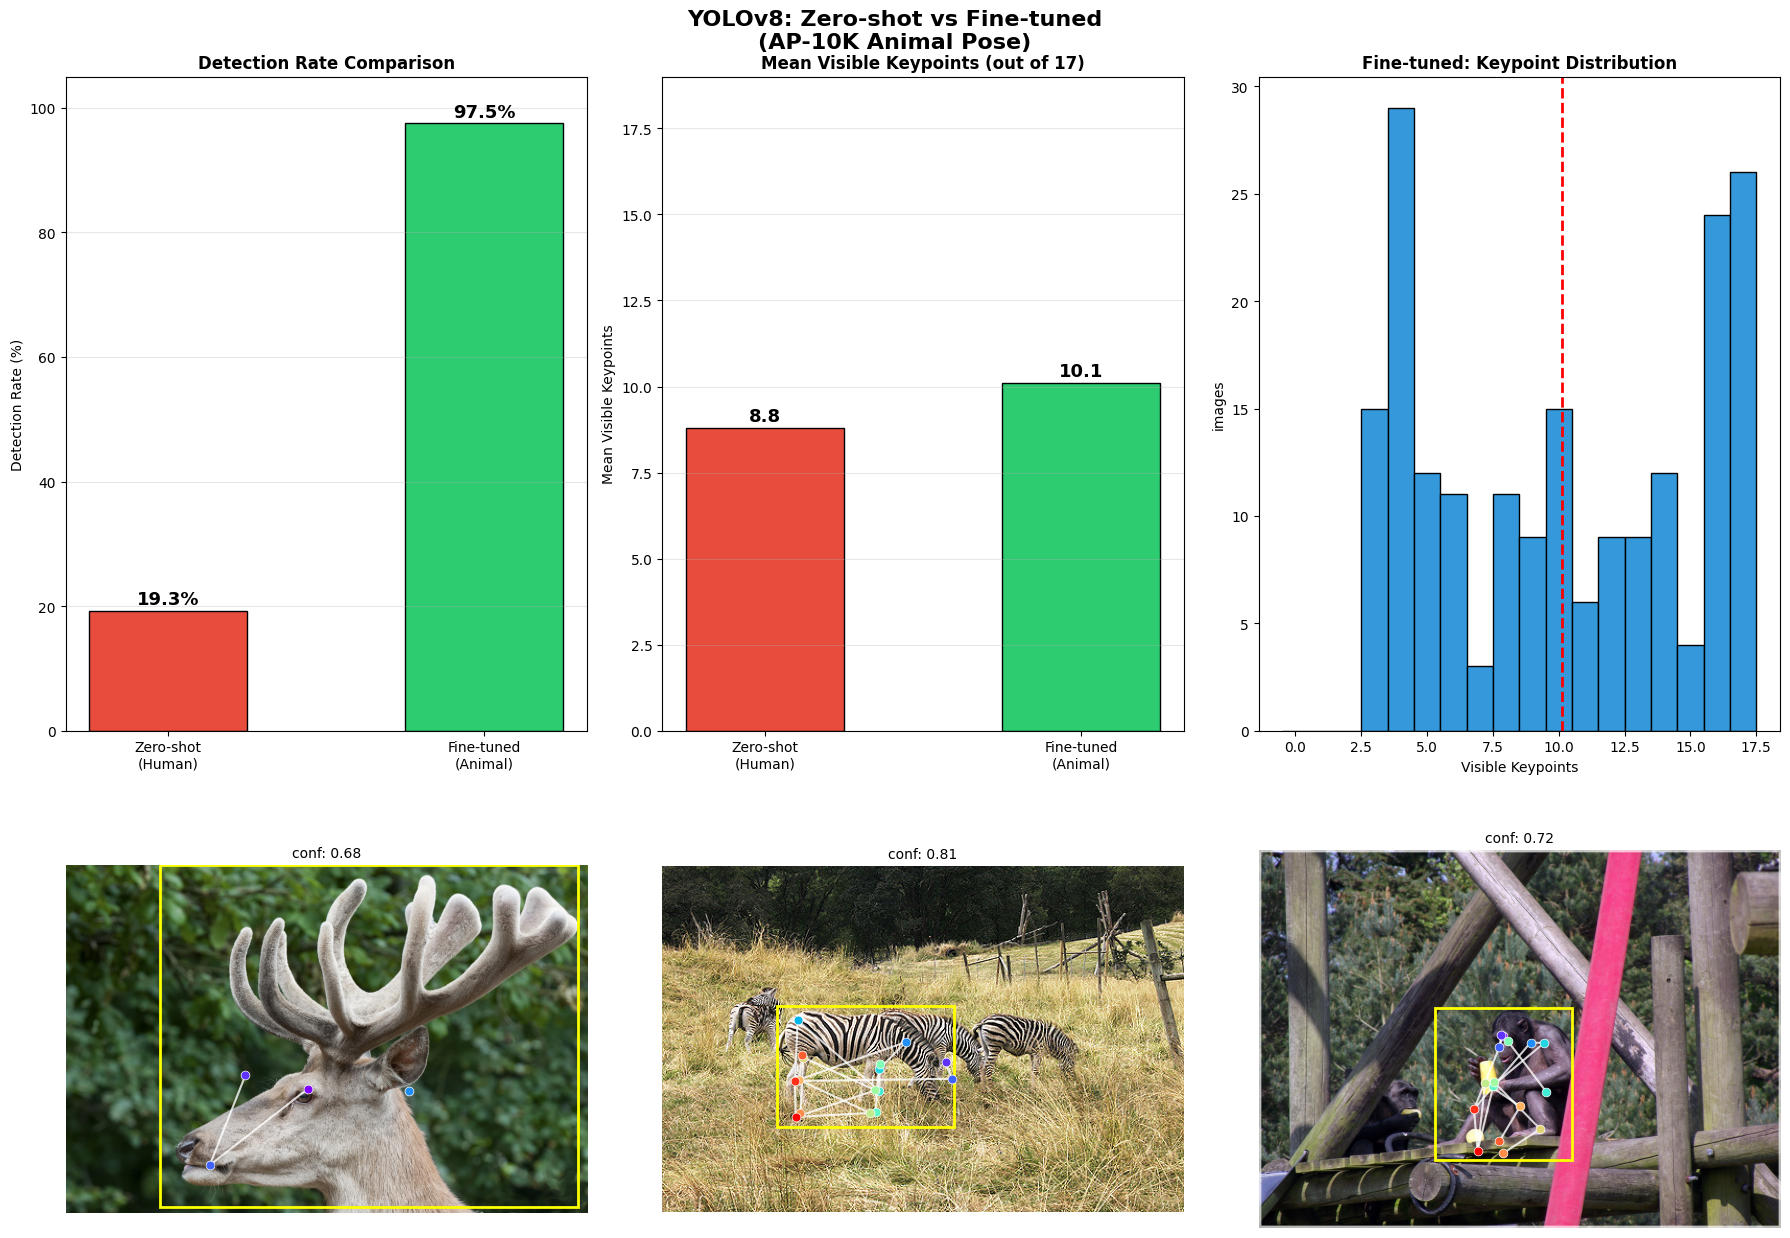

 saved in drive!


In [ ]:
# ============================================================
# Step 5: visualizing
# ============================================================
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib
import cv2
import numpy as np


fig = plt.figure(figsize=(18, 14))
fig.suptitle('YOLOv8: Zero-shot vs Fine-tuned\n(AP-10K Animal Pose)', fontsize=16, fontweight='bold')

# ── graph 1: Detection Rate ──
ax1 = fig.add_subplot(2, 3, 1)
bars = ax1.bar(['Zero-shot\n(Human)', 'Fine-tuned\n(Animal)'],
               [19.3, det_rate], color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, [19.3, det_rate]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax1.set_ylim(0, 105); ax1.set_ylabel('Detection Rate (%)'); ax1.grid(axis='y', alpha=0.3)
ax1.set_title('Detection Rate Comparison', fontweight='bold')

# ── graph 2: Mean Visible Keypoints ──
ax2 = fig.add_subplot(2, 3, 2)
bars2 = ax2.bar(['Zero-shot\n(Human)', 'Fine-tuned\n(Animal)'],
                [8.8, mean_vis], color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars2, [8.8, mean_vis]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.1f}', ha='center', fontweight='bold', fontsize=13)
ax2.set_ylim(0, 19); ax2.set_ylabel('Mean Visible Keypoints'); ax2.grid(axis='y', alpha=0.3)
ax2.set_title('Mean Visible Keypoints (out of 17)', fontweight='bold')

# ── graph 3: Keypoint Distribution Histogram ──
ax3 = fig.add_subplot(2, 3, 3)
ax3.hist(visible_kpt_counts, bins=range(0, 19), color='#3498db', edgecolor='black', align='left')
ax3.axvline(mean_vis, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_vis:.1f}')
ax3.set_xlabel('Visible Keypoints'); ax3.set_ylabel('images')
ax3.set_title('Fine-tuned: Keypoint Distribution', fontweight='bold')

# ── graph 4~6: Visualization of actual prediction images ──
SKELETON = [(0,2),(1,2),(2,15),(15,3),(15,4),(3,5),(4,6),(5,7),(6,8),
            (15,16),(16,9),(16,10),(9,11),(10,12),(11,13),(12,14)]
KPT_COLORS = plt.cm.rainbow(np.linspace(0, 1, 17))

detected = []
for fname in test_sample:
    r = ft_model(os.path.join(val_img_dir, fname), conf=0.25, verbose=False)[0]
    if r.keypoints is not None and len(r.keypoints.data) > 0:
        detected.append((fname, r))
    if len(detected) >= 3:
        break

for idx, (fname, r) in enumerate(detected[:3]):
    ax = fig.add_subplot(2, 3, 4+idx)
    img = cv2.cvtColor(cv2.imread(os.path.join(val_img_dir, fname)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    box = r.boxes.xyxy[0].cpu().numpy()
    ax.add_patch(mpatches.Rectangle((box[0],box[1]), box[2]-box[0], box[3]-box[1],
                                     linewidth=2, edgecolor='yellow', facecolor='none'))

    kpts = r.keypoints.data[0].cpu().numpy()
    for k, (kx, ky, kc) in enumerate(kpts):
        if kc > 0.3:
            ax.scatter(kx, ky, c=[KPT_COLORS[k]], s=40, zorder=5, edgecolors='white', linewidths=0.5)
    for (a, b) in SKELETON:
        if kpts[a][2] > 0.3 and kpts[b][2] > 0.3:
            ax.plot([kpts[a][0],kpts[b][0]], [kpts[a][1],kpts[b][1]], 'w-', linewidth=1.5, alpha=0.8)

    ax.set_title(f'conf: {r.boxes.conf[0].item():.2f}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/yolov8_finetuned_results.png', dpi=150, bbox_inches='tight')
plt.show()
!cp /content/yolov8_finetuned_results.png '/content/drive/MyDrive/yolov8_finetuned_results.png'
print(" saved in drive!")